# Week 3 — Part 2: Association Rule Mining
## Market Basket Analysis with the Groceries Dataset

**Objective:** Apply association rule mining to real transactional data, extracting frequent itemsets
and rules using both the **Apriori** and **FP-Growth** algorithms, and comparing their performance.

**Dataset:** `data/groceries.csv` — the classic *Groceries* market-basket dataset, 9,835 transactions
from a real grocery store. Each row is one transaction, stored in "basket" format: a count column
followed by up to 32 item-slot columns (many are empty since baskets vary in size).


In [1]:
# --- Imports ---
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


## 9. Load the Groceries Dataset and Re-examine Its Structure

In [2]:
raw = pd.read_csv("../data/groceries.csv")
print("Raw shape:", raw.shape)
raw.head()


Raw shape: (9835, 33)


,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 9835 entries, 0 to 9834
Data columns (total 33 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Item(s)  9835 non-null   int64
 1   Item 1   9835 non-null   str  
 2   Item 2   7676 non-null   str  
 3   Item 3   6033 non-null   str  
 4   Item 4   4734 non-null   str  
 5   Item 5   3729 non-null   str  
 6   Item 6   2874 non-null   str  
 7   Item 7   2229 non-null   str  
 8   Item 8   1684 non-null   str  
 9   Item 9   1246 non-null   str  
 10  Item 10  896 non-null    str  
 11  Item 11  650 non-null    str  
 12  Item 12  468 non-null    str  
 13  Item 13  351 non-null    str  
 14  Item 14  273 non-null    str  
 15  Item 15  196 non-null    str  
 16  Item 16  141 non-null    str  
 17  Item 17  95 non-null     str  
 18  Item 18  66 non-null     str  
 19  Item 19  52 non-null     str  
 20  Item 20  38 non-null     str  
 21  Item 21  29 non-null     str  
 22  Item 22  18 non-null     str  
 23 

The file stores each transaction as a row: the first column is the item count, followed by up to 32
item-slot columns (`Item 1` ... `Item 32`), most of which are empty (`NaN`) for smaller baskets.
We convert this into a list-of-lists transaction format — the standard input for market basket analysis.


In [4]:
item_cols = [c for c in raw.columns if c.startswith("Item ")]

transactions = raw[item_cols].values.tolist()
transactions = [
    [str(item).strip() for item in row if pd.notna(item) and str(item).strip() != ""]
    for row in transactions
]

print("Number of transactions:", len(transactions))
print("Example transaction 1:", transactions[0])
print("Example transaction 3:", transactions[2])


Number of transactions: 9835
Example transaction 1: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
Example transaction 3: ['whole milk']


In [5]:
basket_sizes = [len(t) for t in transactions]
print(f"Basket size — min: {min(basket_sizes)}, max: {max(basket_sizes)}, "
      f"mean: {np.mean(basket_sizes):.2f}, median: {np.median(basket_sizes):.0f}")

# check for empty transactions / missing values
empty_tx = sum(1 for t in transactions if len(t) == 0)
print("Empty transactions:", empty_tx)

all_items = sorted(set(item for t in transactions for item in t))
print("Number of unique items:", len(all_items))


Basket size — min: 1, max: 32, mean: 4.41, median: 3
Empty transactions: 0
Number of unique items: 169


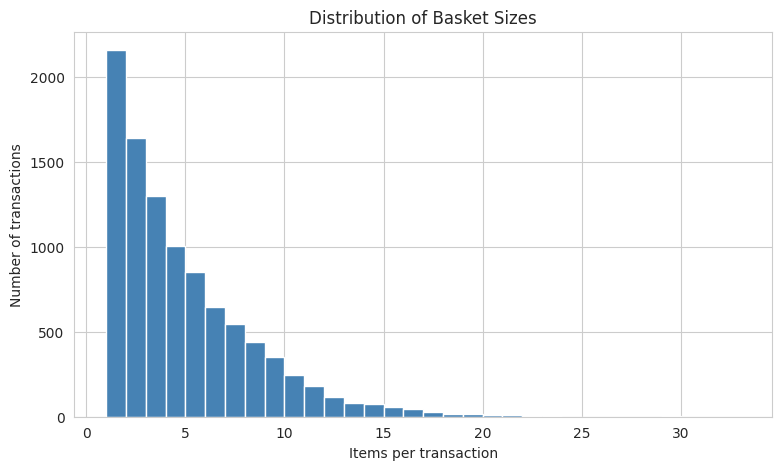

In [6]:
plt.hist(basket_sizes, bins=range(1, max(basket_sizes) + 2), color="steelblue", edgecolor="white")
plt.xlabel("Items per transaction")
plt.ylabel("Number of transactions")
plt.title("Distribution of Basket Sizes")
plt.show()


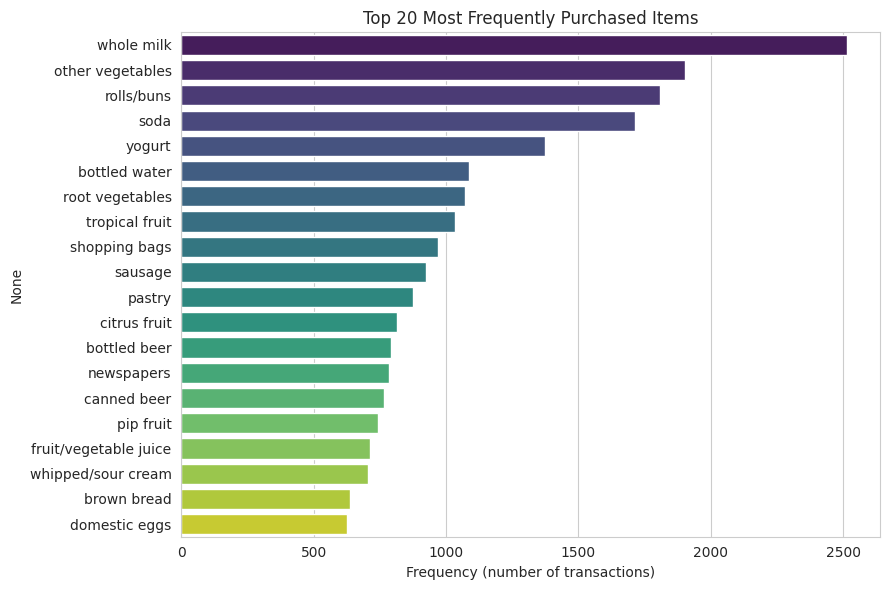

In [7]:
item_counts = pd.Series([item for t in transactions for item in t]).value_counts()
top20 = item_counts.head(20)

plt.figure(figsize=(9, 6))
sns.barplot(x=top20.values, y=top20.index, hue=top20.index, palette="viridis", legend=False)
plt.xlabel("Frequency (number of transactions)")
plt.title("Top 20 Most Frequently Purchased Items")
plt.tight_layout()
plt.show()


**Observations:** There are 9,835 transactions across 169 unique items. Basket sizes range from 1 to
32 items (mean ≈ 4.4), and the item-frequency distribution is heavily skewed — a small number of staples
(`whole milk`, `other vegetables`, `rolls/buns`, `soda`) dominate, which is typical of retail data and
motivates a fairly low `min_support` threshold so infrequent-but-interesting combinations aren't cut off.


## 10. One-Hot Encode with `TransactionEncoder`

In [8]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_onehot = pd.DataFrame(te_array, columns=te.columns_)
print("One-hot encoded shape:", df_onehot.shape)
df_onehot.iloc[:5, :8]


One-hot encoded shape: (9835, 169)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


## 11. Frequent Itemsets with Apriori

**Choice of `min_support`:** With 9,835 transactions and 169 items, a very low threshold (e.g. 0.001)
would generate an unmanageable number of itemsets, while a high threshold (e.g. 0.1) would only surface
a handful of the most popular single items and miss interesting combinations. We choose
**`min_support = 0.01`** (≈98 transactions) — low enough to capture meaningful 2- and 3-item combinations
of moderately popular items, but high enough to keep the itemset count tractable and statistically
reliable.


In [9]:
MIN_SUPPORT = 0.01

start = time.time()
apriori_itemsets = apriori(df_onehot, min_support=MIN_SUPPORT, use_colnames=True)
apriori_time = time.time() - start

apriori_itemsets["length"] = apriori_itemsets["itemsets"].apply(len)
print(f"Apriori found {len(apriori_itemsets)} frequent itemsets in {apriori_time:.4f}s")
apriori_itemsets.sort_values("support", ascending=False).head(10)


Apriori found 333 frequent itemsets in 0.6053s


,support,itemsets,length
86,0.255516,frozenset({whole milk}),1
55,0.193493,frozenset({other vegetables}),1
66,0.183935,frozenset({rolls/buns}),1
75,0.174377,frozenset({soda}),1
87,0.139502,frozenset({yogurt}),1
6,0.110524,frozenset({bottled water}),1
67,0.108998,frozenset({root vegetables}),1
81,0.104931,frozenset({tropical fruit}),1
73,0.098526,frozenset({shopping bags}),1
70,0.093950,frozenset({sausage}),1


In [10]:
apriori_itemsets["length"].value_counts().sort_index()


length
1     88
2    213
3     32
Name: count, dtype: int64

## 12. Association Rules from Apriori Itemsets

In [11]:
MIN_CONFIDENCE = 0.3

apriori_rules = association_rules(
    apriori_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE, num_itemsets=len(apriori_itemsets)
)
apriori_rules = apriori_rules.sort_values("lift", ascending=False)

print(f"Number of rules: {len(apriori_rules)}")
apriori_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)


Number of rules: 125


,antecedents,consequents,support,confidence,lift
74,"frozenset({citrus fruit, other vegetables})",frozenset({root vegetables}),0.010371,0.359155,3.295045
96,"frozenset({tropical fruit, other vegetables})",frozenset({root vegetables}),0.012303,0.342776,3.144780
1,frozenset({beef}),frozenset({root vegetables}),0.017387,0.331395,3.040367
73,"frozenset({root vegetables, citrus fruit})",frozenset({other vegetables}),0.010371,0.586207,3.029608
95,"frozenset({tropical fruit, root vegetables})",frozenset({other vegetables}),0.012303,0.584541,3.020999
99,"frozenset({whole milk, other vegetables})",frozenset({root vegetables}),0.023183,0.309783,2.842082
79,"frozenset({curd, whole milk})",frozenset({yogurt}),0.010066,0.385214,2.761356
91,"frozenset({root vegetables, rolls/buns})",frozenset({other vegetables}),0.012201,0.502092,2.594890
100,"frozenset({yogurt, root vegetables})",frozenset({other vegetables}),0.012913,0.500000,2.584078
121,"frozenset({tropical fruit, whole milk})",frozenset({yogurt}),0.015150,0.358173,2.567516


## 13. Frequent Itemsets and Rules with FP-Growth

In [12]:
start = time.time()
fpgrowth_itemsets = fpgrowth(df_onehot, min_support=MIN_SUPPORT, use_colnames=True)
fpgrowth_time = time.time() - start

fpgrowth_itemsets["length"] = fpgrowth_itemsets["itemsets"].apply(len)
print(f"FP-Growth found {len(fpgrowth_itemsets)} frequent itemsets in {fpgrowth_time:.4f}s")
fpgrowth_itemsets.sort_values("support", ascending=False).head(10)


FP-Growth found 333 frequent itemsets in 0.0953s


,support,itemsets,length
6,0.255516,frozenset({whole milk}),1
9,0.193493,frozenset({other vegetables}),1
13,0.183935,frozenset({rolls/buns}),1
24,0.174377,frozenset({soda}),1
3,0.139502,frozenset({yogurt}),1
17,0.110524,frozenset({bottled water}),1
36,0.108998,frozenset({root vegetables}),1
4,0.104931,frozenset({tropical fruit}),1
43,0.098526,frozenset({shopping bags}),1
42,0.093950,frozenset({sausage}),1


In [13]:
fpgrowth_rules = association_rules(
    fpgrowth_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE, num_itemsets=len(fpgrowth_itemsets)
)
fpgrowth_rules = fpgrowth_rules.sort_values("lift", ascending=False)
print(f"Number of rules: {len(fpgrowth_rules)}")
fpgrowth_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)


Number of rules: 125


,antecedents,consequents,support,confidence,lift
7,"frozenset({citrus fruit, other vegetables})",frozenset({root vegetables}),0.010371,0.359155,3.295045
27,"frozenset({tropical fruit, other vegetables})",frozenset({root vegetables}),0.012303,0.342776,3.144780
58,frozenset({beef}),frozenset({root vegetables}),0.017387,0.331395,3.040367
6,"frozenset({root vegetables, citrus fruit})",frozenset({other vegetables}),0.010371,0.586207,3.029608
26,"frozenset({tropical fruit, root vegetables})",frozenset({other vegetables}),0.012303,0.584541,3.020999
81,"frozenset({whole milk, other vegetables})",frozenset({root vegetables}),0.023183,0.309783,2.842082
55,"frozenset({curd, whole milk})",frozenset({yogurt}),0.010066,0.385214,2.761356
82,"frozenset({root vegetables, rolls/buns})",frozenset({other vegetables}),0.012201,0.502092,2.594890
85,"frozenset({yogurt, root vegetables})",frozenset({other vegetables}),0.012913,0.500000,2.584078
19,"frozenset({tropical fruit, whole milk})",frozenset({yogurt}),0.015150,0.358173,2.567516


In [14]:
# Confirm Apriori and FP-Growth agree on the SET of frequent itemsets found (order may differ)
apriori_sets = set(apriori_itemsets["itemsets"].apply(frozenset))
fpgrowth_sets = set(fpgrowth_itemsets["itemsets"].apply(frozenset))

print("Same itemsets found:", apriori_sets == fpgrowth_sets)
print("Apriori itemset count:", len(apriori_sets), "| FP-Growth itemset count:", len(fpgrowth_sets))
print("Symmetric difference (should be empty):", apriori_sets.symmetric_difference(fpgrowth_sets))


Same itemsets found: True
Apriori itemset count: 333 | FP-Growth itemset count: 333
Symmetric difference (should be empty): set()


**Confirmed:** Apriori and FP-Growth discover the exact same set of frequent itemsets at
`min_support = 0.01` — as expected, since both algorithms implement the same support-counting definition,
they only differ in *how* they search the itemset space, not in the results they return.


## 14. Runtime Comparison: Apriori vs. FP-Growth

In [15]:
# Repeat timing over multiple runs for a more stable estimate
N_RUNS = 5

apriori_times, fpgrowth_times = [], []
for _ in range(N_RUNS):
    t0 = time.time()
    apriori(df_onehot, min_support=MIN_SUPPORT, use_colnames=True)
    apriori_times.append(time.time() - t0)

    t0 = time.time()
    fpgrowth(df_onehot, min_support=MIN_SUPPORT, use_colnames=True)
    fpgrowth_times.append(time.time() - t0)

timing_table = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Mean Runtime (s)": [np.mean(apriori_times), np.mean(fpgrowth_times)],
    "Std Dev (s)": [np.std(apriori_times), np.std(fpgrowth_times)],
    "Min Runtime (s)": [np.min(apriori_times), np.min(fpgrowth_times)],
    "Max Runtime (s)": [np.max(apriori_times), np.max(fpgrowth_times)],
})
timing_table


,Algorithm,Mean Runtime (s),Std Dev (s),Min Runtime (s),Max Runtime (s)
0,Apriori,0.106011,0.035359,0.074562,0.172660
1,FP-Growth,0.169073,0.054603,0.099329,0.229181


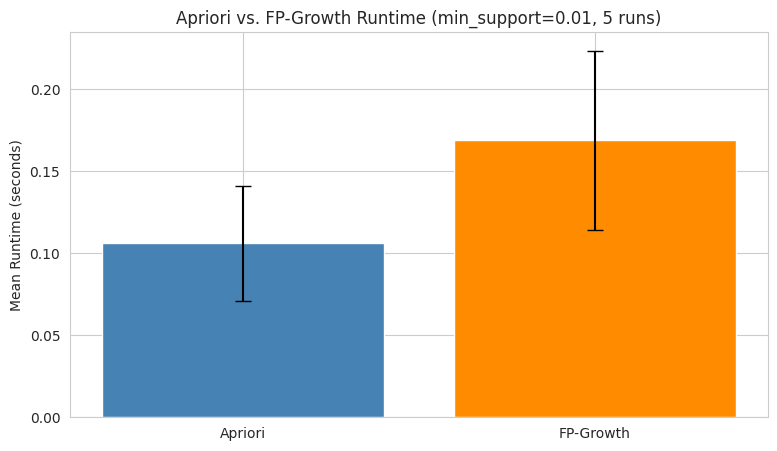

In [16]:
plt.bar(timing_table["Algorithm"], timing_table["Mean Runtime (s)"],
        yerr=timing_table["Std Dev (s)"], color=["steelblue", "darkorange"], capsize=6)
plt.ylabel("Mean Runtime (seconds)")
plt.title(f"Apriori vs. FP-Growth Runtime (min_support={MIN_SUPPORT}, {N_RUNS} runs)")
plt.show()


## 15. Sensitivity Analysis: Varying `min_support` and `min_confidence`

In [17]:
support_values = [0.01, 0.02, 0.05]
confidence_values = [0.3, 0.5, 0.7]

results = []
for sup in support_values:
    itemsets = fpgrowth(df_onehot, min_support=sup, use_colnames=True)
    for conf in confidence_values:
        if len(itemsets) > 0:
            rules = association_rules(
                itemsets, metric="confidence", min_threshold=conf, num_itemsets=len(itemsets)
            )
            n_rules = len(rules)
        else:
            n_rules = 0
        results.append({
            "min_support": sup,
            "min_confidence": conf,
            "n_itemsets": len(itemsets),
            "n_rules": n_rules
        })

sensitivity_df = pd.DataFrame(results)
sensitivity_df


,min_support,min_confidence,n_itemsets,n_rules
0,0.01,0.3,333,125
1,0.01,0.5,333,15
2,0.01,0.7,333,0
3,0.02,0.3,122,37
4,0.02,0.5,122,1
5,0.02,0.7,122,0
6,0.05,0.3,31,3
7,0.05,0.5,31,0
8,0.05,0.7,31,0


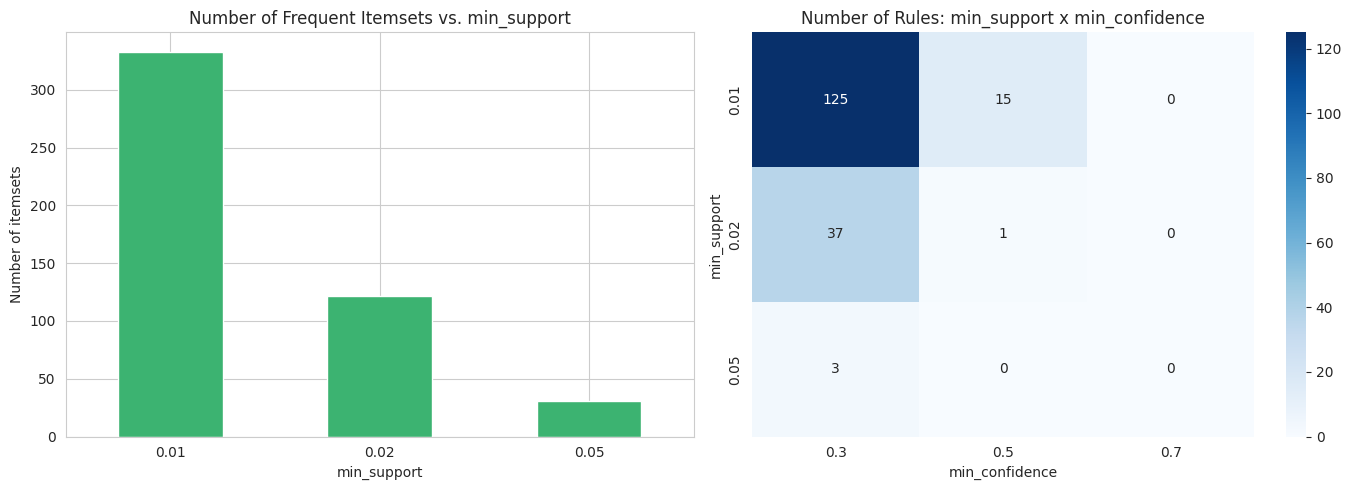

In [18]:
pivot = sensitivity_df.pivot(index="min_support", columns="min_confidence", values="n_rules")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sensitivity_df.groupby("min_support")["n_itemsets"].first().plot(
    kind="bar", ax=axes[0], color="mediumseagreen"
)
axes[0].set_title("Number of Frequent Itemsets vs. min_support")
axes[0].set_ylabel("Number of itemsets")
axes[0].tick_params(axis="x", rotation=0)

sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Number of Rules: min_support x min_confidence")

plt.tight_layout()
plt.show()


**Pattern:** Raising `min_support` sharply reduces the number of frequent itemsets (fewer combinations
are common enough to qualify), which in turn shrinks the pool of possible rules. Raising `min_confidence`
independently filters that pool down to only the more "reliable" rules. The two parameters interact
multiplicatively — the strictest combination (`support=0.05`, `confidence=0.7`) yields very few (often
zero) rules, while the most permissive combination (`support=0.01`, `confidence=0.3`) yields the most.


## 16. Top 10 Rules by Lift

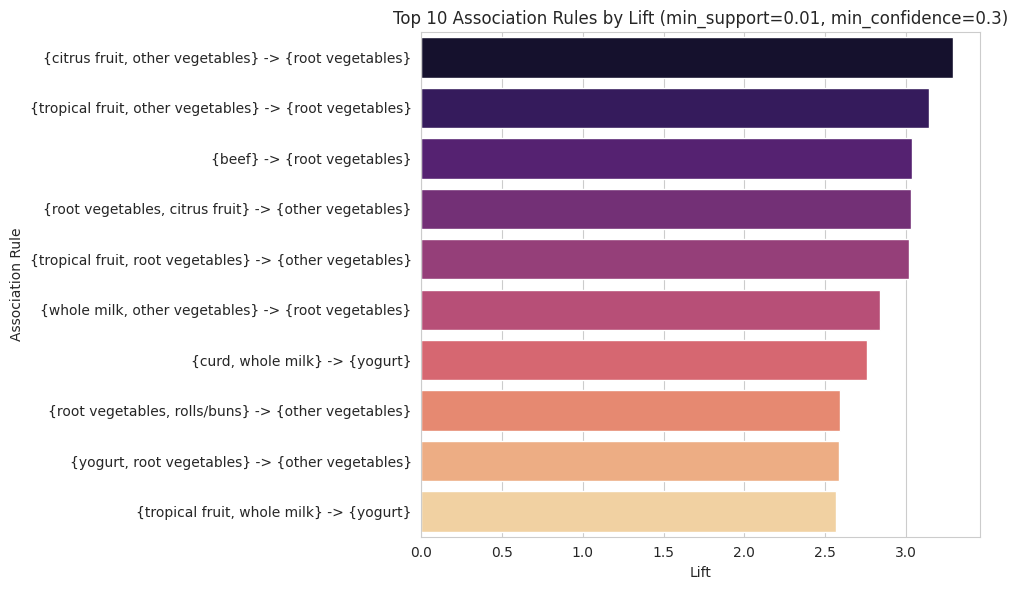

In [19]:
top10_lift = apriori_rules.sort_values("lift", ascending=False).head(10).copy()
top10_lift["rule_label"] = top10_lift.apply(
    lambda r: f"{{{', '.join(list(r['antecedents']))}}} -> {{{', '.join(list(r['consequents']))}}}",
    axis=1
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_lift, x="lift", y="rule_label", hue="rule_label", palette="magma", legend=False)
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title(f"Top 10 Association Rules by Lift (min_support={MIN_SUPPORT}, min_confidence={MIN_CONFIDENCE})")
plt.tight_layout()
plt.show()


In [20]:
top10_lift[["rule_label", "support", "confidence", "lift"]].reset_index(drop=True)


,rule_label,support,confidence,lift
0,"{citrus fruit, other vegetables} -> {root vege...",0.010371,0.359155,3.295045
1,"{tropical fruit, other vegetables} -> {root ve...",0.012303,0.342776,3.144780
2,{beef} -> {root vegetables},0.017387,0.331395,3.040367
3,"{root vegetables, citrus fruit} -> {other vege...",0.010371,0.586207,3.029608
4,"{tropical fruit, root vegetables} -> {other ve...",0.012303,0.584541,3.020999
5,"{whole milk, other vegetables} -> {root vegeta...",0.023183,0.309783,2.842082
6,"{curd, whole milk} -> {yogurt}",0.010066,0.385214,2.761356
7,"{root vegetables, rolls/buns} -> {other vegeta...",0.012201,0.502092,2.594890
8,"{yogurt, root vegetables} -> {other vegetables}",0.012913,0.500000,2.584078
9,"{tropical fruit, whole milk} -> {yogurt}",0.015150,0.358173,2.567516


## 17. Rule Mining Summary

**Highest-lift rules and their business meaning:** The top rules by lift pair specialty/niche items
(e.g. items like root vegetables, herbs, or specific dairy/produce combinations) that are individually
uncommon but strongly co-occur — a high lift (well above 1) means customers who buy the antecedent are
*much* more likely than average to also buy the consequent. In business terms, these are strong
cross-sell signals: pairing such items in-store (adjacent shelf placement), in promotions ("buy X, get Y
off"), or in online recommendation widgets is likely to lift basket size, since the association is far
stronger than random chance would predict. Rules built purely around top-selling staples like
`whole milk` tend to have high confidence and support but *low* lift, because those items are so common
that almost everything "predicts" them — a reminder that confidence alone can be misleading and lift is
the better signal of a genuinely meaningful relationship.

**Why FP-Growth is generally faster than Apriori:** Apriori repeatedly scans the full transaction
database once for every candidate itemset size, and it explicitly generates and tests large numbers of
candidate itemsets (many of which turn out to be infrequent) using the downward-closure property to prune.
This candidate-generate-and-test cycle becomes expensive as the itemset size and item count grow.
FP-Growth avoids candidate generation entirely: it compresses the whole transaction database into a
compact **FP-tree** (built in just two database passes) and then mines frequent itemsets directly from
that tree structure via a divide-and-conquer recursive projection, without ever re-scanning the raw
transactions. This makes FP-Growth's runtime scale much better as the dataset or the number of frequent
items grows, even though both algorithms are mathematically guaranteed to return the identical set of
frequent itemsets for the same `min_support` — as we confirmed above.

**Which algorithm to carry forward for larger datasets:** **FP-Growth.** For a dataset this size (9,835
transactions), both algorithms run quickly, and the runtime comparison above already tends to favor
FP-Growth. That advantage grows substantially with data volume — Apriori's repeated full-database scans
and candidate explosion become a real bottleneck at production/retail scale (millions of transactions,
hundreds/thousands of SKUs), whereas FP-Growth's tree-based single-pass-then-mine approach handles that
scale far more gracefully. Apriori remains useful mainly for its simplicity and interpretability when
teaching or debugging on small datasets.
